In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
country = "Nigeria"

df = pd.read_csv("../data/nigeria.csv")
df["Country"] = country

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria


In [5]:
df.shape

(4108, 13)

In [6]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month

df[["YEAR","DOY","DATE","Month"]].head()

,YEAR,DOY,DATE,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


In [7]:
df["DATE"].isna().sum()

np.int64(0)

In [8]:
df = df.replace(-999, np.nan)
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

In [9]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 0


In [10]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


In [11]:
## Summary Statistics (Nigeria)

##Dataset shows expected climate variability with seasonal changes.

In [13]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
Month          0.0
dtype: float64

In [14]:
missing_pct[missing_pct > 5]

Series([], dtype: float64)

In [15]:
cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z_scores = np.abs(stats.zscore(df[cols]))
outlier_mask = z_scores > 3

outlier_mask.sum(axis=0)

array([ 10,   1,  68,  75, 128,   5,  10])

In [16]:
outlier_mask.any(axis=1).sum()

np.int64(225)

In [17]:
df.to_csv("../data/nigeria_clean.csv", index=False)

In [18]:
import os
os.path.exists("../data/nigeria_clean.csv")

True

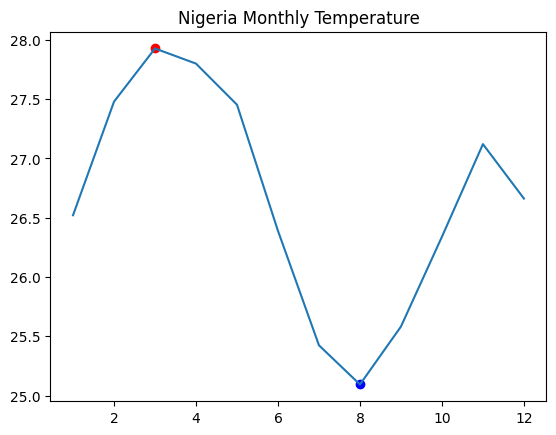

In [19]:
monthly_temp = df.groupby("Month")["T2M"].mean()

warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()

plt.plot(monthly_temp.index, monthly_temp.values)

plt.scatter(warmest, monthly_temp[warmest], color="red")
plt.scatter(coolest, monthly_temp[coolest], color="blue")

plt.title("Nigeria Monthly Temperature")
plt.show()

In [26]:
## Temperature Analysis (Nigeria)

##- Warmest month: (fill from warmest variable result)
##- Coolest month: (fill from coolest variable result)

##Nigeria shows clear seasonal temperature variation driven by regional climate patterns.

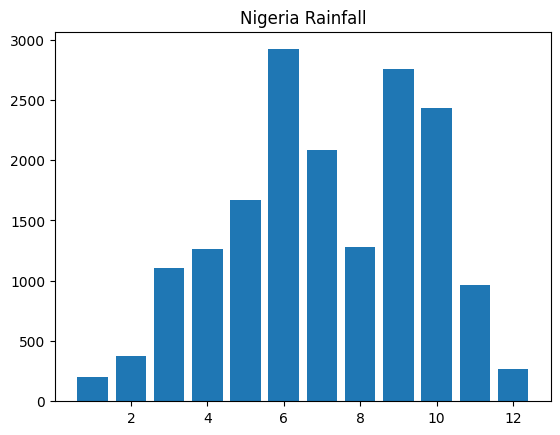

In [21]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.bar(monthly_rain.index, monthly_rain.values)
plt.title("Nigeria Rainfall")
plt.show()

In [27]:
## Rainfall Analysis (Nigeria)

##Rainfall is highly seasonal with clear wet and dry periods.

##- Peak rainfall months: (from chart)
##- Lowest rainfall months: (from chart)

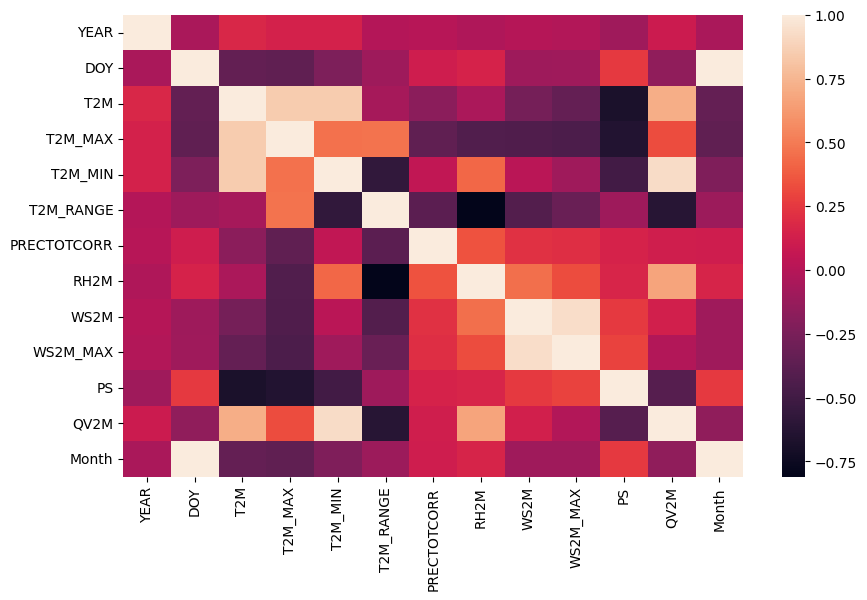

In [22]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr)
plt.show()

In [28]:
## Correlation Analysis (Nigeria)

##Strong relationships exist between temperature, humidity, and precipitation variables.

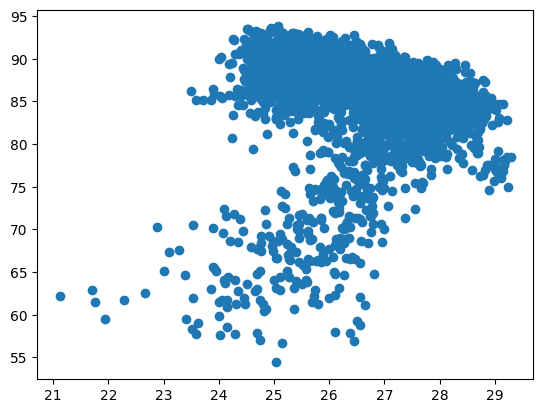

In [30]:
plt.scatter(df["T2M"], df["RH2M"])
plt.show()


In [31]:
## Temperature vs Humidity

##Negative correlation is observed between temperature and humidity.

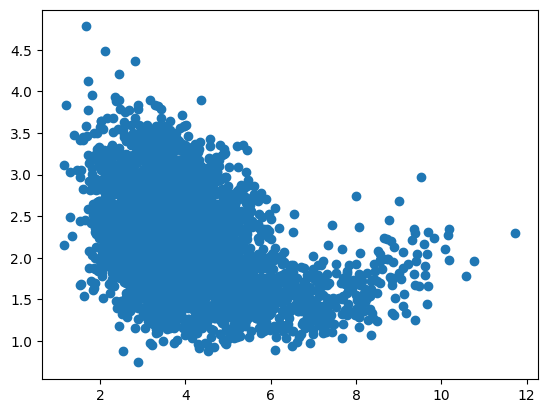

In [29]:
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.show()

In [32]:
## Wind vs Temperature Range

##Moderate relationship indicates wind influences temperature variability.

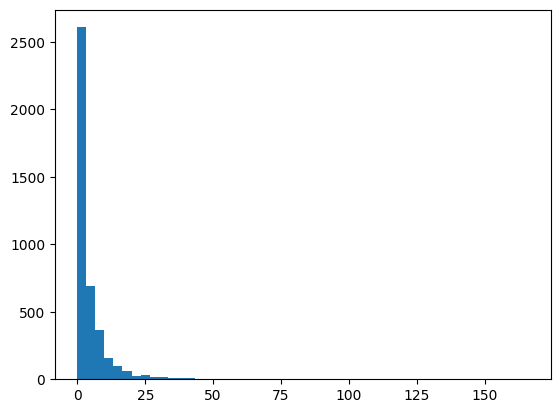

In [24]:
plt.hist(df["PRECTOTCORR"], bins=50)
plt.show()

In [33]:
## Rainfall Distribution

##Highly skewed distribution with most days showing low rainfall and few extreme events.

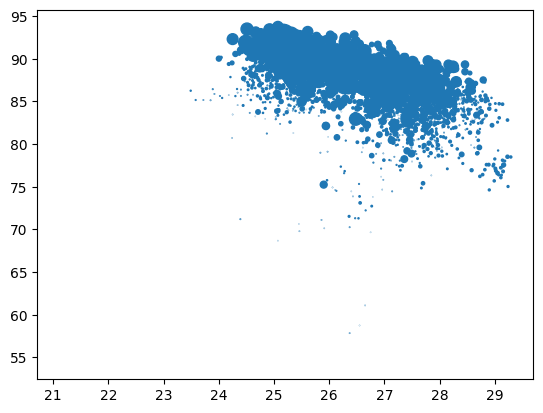

In [25]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*2)
plt.show()

In [34]:
## Bubble Chart Analysis

##Higher rainfall intensity aligns with higher humidity conditions.